In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [20]:
df = pd.read_csv('/content/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [21]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [22]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


Text(0, 0.5, 'No of Houses')

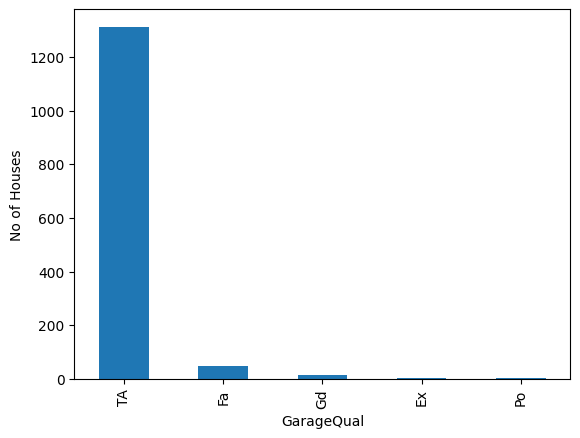

In [23]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('No of Houses')

In [24]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'GarageQual')

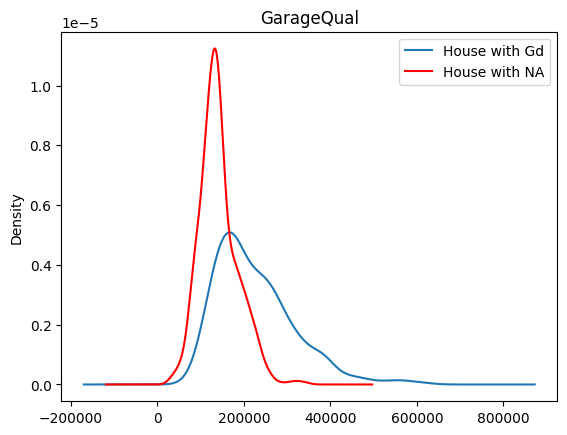

In [35]:
fig=plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['House with Gd','House with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')


In [26]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [28]:
df['GarageQual'].fillna('TA',inplace=True)

<Axes: xlabel='GarageQual'>

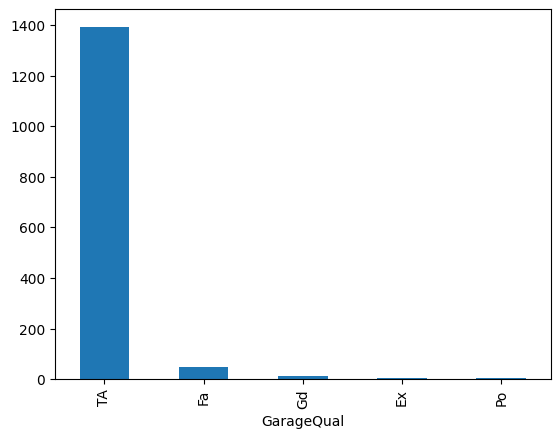

In [29]:
df['GarageQual'].value_counts().plot.bar()

Text(0.5, 1.0, 'GarageQual')

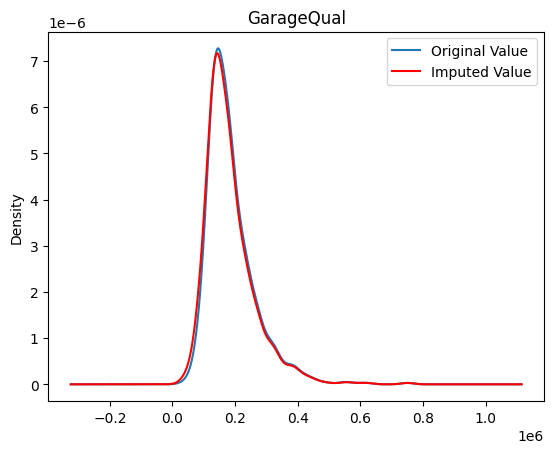

In [31]:
fig=plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original Value','Imputed Value ']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

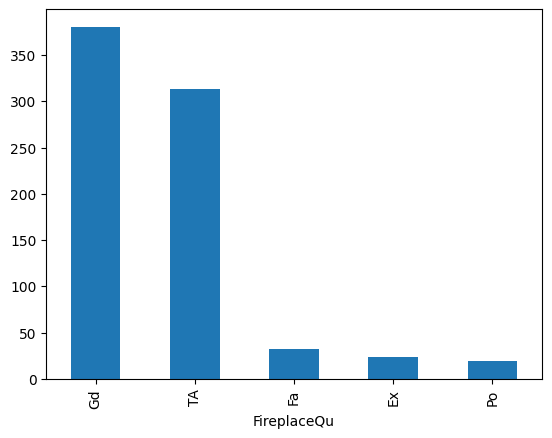

In [32]:
df['FireplaceQu'].value_counts().plot.bar()

In [33]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


In [36]:
temp1=df[df['FireplaceQu']=='Gd']['SalePrice']

In [38]:
df['FireplaceQu'].fillna('Gd',inplace=True)

<Axes: xlabel='FireplaceQu'>

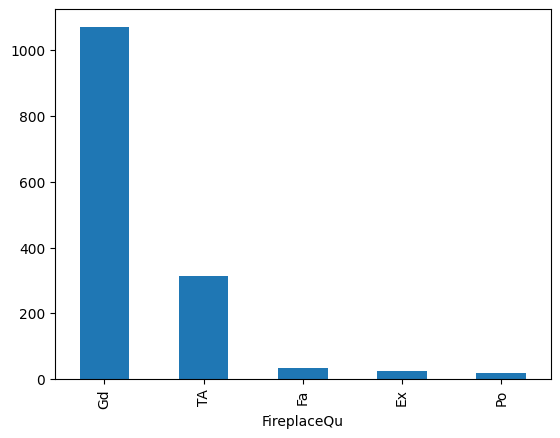

In [40]:
df['FireplaceQu'].value_counts().plot.bar()

Text(0.5, 1.0, 'GarageQual')

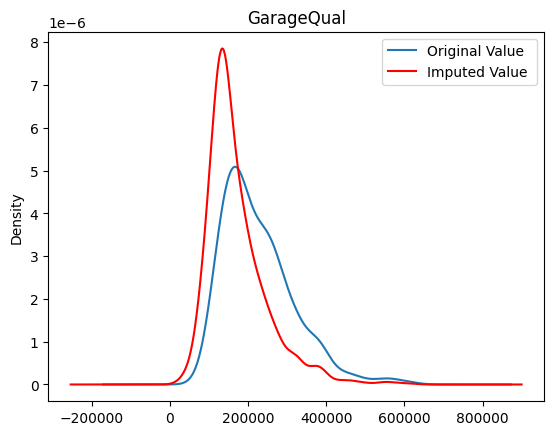

In [39]:
fig=plt.figure()
ax = fig.add_subplot(111)

temp1.plot(kind='kde',ax=ax)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original Value','Imputed Value ']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

In [41]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [42]:
imputer=SimpleImputer(strategy='most_frequent')

In [44]:
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [45]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)